In [1]:
!pip install duckdb

# Importing DuckDB to run SQL queries

In [1]:
import duckdb

# Exploring the data

In [2]:
duckdb.sql(f"""
SELECT *
FROM read_csv_auto('accounts.csv')
LIMIT 10;
""").show()

┌─────────────┬───────────────────────────┬────────────────┬───────────────────────────────────────────────┬────────────┬───────────────────┬───────────┬───────────────────┬─────────────────────┬──────────────────────────┐
│ customer_id │       company_name        │    country     │                   industry                    │ fleet_size │ subscription_tier │    mrr    │ contract_end_date │ last_login_days_ago │ support_tickets_last_90d │
│   varchar   │          varchar          │    varchar     │                    varchar                    │   int64    │      varchar      │  double   │       date        │        int64        │          int64           │
├─────────────┼───────────────────────────┼────────────────┼───────────────────────────────────────────────┼────────────┼───────────────────┼───────────┼───────────────────┼─────────────────────┼──────────────────────────┤
│ CUST-001    │ Crawford Haulage          │ United Kingdom │ "Transportation and Warehousing"              │

# At-risk SQL Model

# Methodology:

### Data Ingestion: Account data is loaded from accounts.csv into DuckDB, including MRR, fleet size, usage, support tickets, and contract dates.

### Feature Benchmarking: Percentiles (25th, 50th, 75th) are calculated for key metrics to create dynamic, data-driven thresholds.

### Risk Scoring: Each account is scored across four dimensions:
*   Fleet Risk (10%)
*   Engagement Risk (login activity) (35%)
*   Support Risk (ticket volume) (25%)
*   Contract Risk (time to renewal) (30%)

###Weighted Aggregation: A composite Total Risk Score is computed using weighted contributions from each risk driver.


###Segmentation: Accounts are classified into Critical, High, Medium, and Low risk based on the final score.


### Prioritization: A priority score combines risk level with revenue impact (MRR), and top at-risk accounts are ranked for action.

In [3]:
result_df = duckdb.sql(f"""

---FULL BASE OF ACCOUNTS

WITH base AS (
  SELECT * FROM read_csv_auto('accounts.csv')
),

--CREATING PERCENTILES FOR FLEET SIZE, LAST LOGIN DATE, SUPPORT TICKETS AND MRR

 Percentiles AS (
  SELECT
    quantile_cont(fleet_size, 0.25) AS fleet_p25,
    quantile_cont(fleet_size, 0.50) AS fleet_p50,
    quantile_cont(fleet_size, 0.75) AS fleet_p75,
    quantile_cont(last_login_days_ago, 0.25) AS login_p25,
    quantile_cont(last_login_days_ago, 0.50) AS login_p50,
    quantile_cont(last_login_days_ago, 0.75) AS login_p75,
    quantile_cont(support_tickets_last_90d, 0.25) AS ticket_p25,
    quantile_cont(support_tickets_last_90d, 0.50) AS ticket_p50,
    quantile_cont(support_tickets_last_90d, 0.75) AS ticket_p75,
    quantile_cont(mrr, 0.25) AS mrr_p25,
    quantile_cont(mrr, 0.50) AS mrr_p50,
    quantile_cont(mrr, 0.75) AS mrr_p75
  FROM base
),

--- CREATING MY RISK SCORING MODEL

RISK_SCORING_MODEL AS (
SELECT
  b.*,
  GREATEST(DATEDIFF('day', CURRENT_DATE, CAST(contract_end_date AS DATE)),0) AS DAYS_TO_CONTRACT_END,

  CASE
    WHEN b.fleet_size <= p.fleet_p25 THEN 60
    WHEN b.fleet_size <= p.fleet_p50 THEN 40
    WHEN b.fleet_size <= p.fleet_p75 THEN 30
    ELSE 10
  END AS fleet_risk,

  CASE
    WHEN b.last_login_days_ago <= p.login_p25 THEN 0
    WHEN b.last_login_days_ago <= p.login_p50 THEN 25
    WHEN b.last_login_days_ago <= p.login_p75 THEN 50
    ELSE 100
  END AS engagement_risk,

  CASE
    WHEN b.support_tickets_last_90d <= p.ticket_p25 THEN 0
    WHEN b.support_tickets_last_90d <= p.ticket_p50 THEN 25
    WHEN b.support_tickets_last_90d <= p.ticket_p75 THEN 50
    ELSE 100
  END AS ticket_risk,

    CASE
      WHEN DAYS_TO_CONTRACT_END < 30 THEN 100
      WHEN DAYS_TO_CONTRACT_END < 90 THEN 70
      WHEN DAYS_TO_CONTRACT_END < 180 THEN 40
      ELSE 0
  END AS CONTRACT_RISK



FROM base b
CROSS JOIN Percentiles AS P),


--- WEIGHTED SCORE USING PERECENTAGES FOR EACH RISK SIGNAL

weighted_risk AS (
  SELECT
    *,
    -- Risk score
    (ENGAGEMENT_RISK * 0.35 +
     TICKET_RISK * 0.25 +
     CONTRACT_RISK * 0.30
     + FLEET_RISK*0.10) AS total_risk_score,

    -- Revenue at risk
    round((MRR * 12),2) AS ANNUAL_CONTRACT_VALUE

  FROM RISK_SCORING_MODEL
),

--- CALCULATING BUSINESS VALUE FOR EACH ACCOUNT
business_value AS (
    SELECT *,
CASE
  WHEN MRR >= mrr_p75 THEN 100
  WHEN MRR >= mrr_p50 THEN 75
  WHEN MRR >= mrr_p25 THEN 50
  ELSE 25
END AS mrr_value_score


    FROM weighted_risk
    cross join Percentiles AS P
),

--- CREATING SEGMENTATION BASED ON RISK SCORES

risk_segmentation AS (
  SELECT
    *,
    CASE
      WHEN total_risk_score >= 70 THEN 'Critical'
      WHEN total_risk_score >= 50 THEN 'High'
      WHEN total_risk_score >= 30 THEN 'Medium'
      ELSE 'Low'
    END AS risk_level,

    -- Priority score combines risk and revenue
  ROUND(total_risk_score * (mrr_value_score / 100.0), 2) priority_score,

    CASE
  WHEN ENGAGEMENT_RISK >= 70 THEN 'Usage Drop'
  WHEN CONTRACT_RISK >= 70 THEN 'Renewal Pressure'
  WHEN TICKET_RISK >= 70 THEN 'Support Friction'
END AS PRIMARY_RISK_DRIVER,

CONCAT_WS(', ',
  CASE WHEN total_risk_score >= 80 THEN 'Critical Account' END,
  CASE WHEN CONTRACT_RISK >= 70 THEN 'Renewal Risk' END,
  CASE WHEN TICKET_RISK >= 70 THEN 'Support Overload' END,
  CASE WHEN ENGAGEMENT_RISK >= 70 THEN 'Usage Drop' END
) AS ALERTS



  FROM business_value
),

ranked_accounts AS (
    SELECT
        COMPANY_NAME,
        COUNTRY,
        MRR AS AT_RISK_REVENUE,
        (MRR * 12) AS ANNUAL_CONTRACT_VALUE,
        RISK_LEVEL,
        PRIORITY_SCORE,
        PRIMARY_RISK_DRIVER,
        ALERTS,

        ROW_NUMBER() OVER (
            ORDER BY PRIORITY_SCORE DESC
        ) AS RANK

    FROM risk_segmentation
    WHERE RISK_LEVEL IN ('Critical', 'High')
)

SELECT *
FROM ranked_accounts
ORDER BY RANK
LIMIT 20;
""").df()

# Top 20 At-risk Accounts

In [17]:
display_df = result_df.copy()

display_df = display_df[[
    'company_name',
    'country',
    'AT_RISK_REVENUE',
    'risk_level',
    'ANNUAL_CONTRACT_VALUE',
    'priority_score',
    'PRIMARY_RISK_DRIVER',
    'ALERTS'
]]

display_df = display_df.sort_values('priority_score', ascending=False)

display_df.style.format({
    'AT_RISK_REVENUE': '€{:,.0f}',
    'PRIORITY_SCORE': '{:.1f}'
})


,company_name,country,AT_RISK_REVENUE,risk_level,ANNUAL_CONTRACT_VALUE,priority_score,PRIMARY_RISK_DRIVER,ALERTS
0,Crawford Haulage,United Kingdom,"€101,945",Critical,1223339.280000,91.000000,Usage Drop,"Critical Account, Renewal Risk, Support Overload, Usage Drop"
1,Carter Distribution,United Kingdom,"€64,677",Critical,776121.720000,91.000000,Usage Drop,"Critical Account, Renewal Risk, Support Overload, Usage Drop"
2,Rossi Logistics,Italy,"€19,155",Critical,229858.560000,91.000000,Usage Drop,"Critical Account, Renewal Risk, Support Overload, Usage Drop"
3,Rodriguez Logistica,Spain,"€79,437",Critical,953244.600000,82.000000,Usage Drop,"Critical Account, Renewal Risk, Support Overload, Usage Drop"
4,Kelly Haulage UK,United Kingdom,"€34,475",Critical,413698.440000,78.500000,Usage Drop,"Renewal Risk, Usage Drop"
5,Richter Distribution GmbH,Germany,"€97,222",Critical,1166669.640000,72.250000,Usage Drop,"Renewal Risk, Usage Drop"
6,Barker Freight,United Kingdom,"€56,675",Critical,680105.520000,72.250000,Usage Drop,"Renewal Risk, Usage Drop"
7,Van den Berg Transport,Netherlands,"€33,279",Critical,399347.640000,72.250000,Usage Drop,"Renewal Risk, Usage Drop"
8,Reid Freight,United Kingdom,"€17,714",Critical,212573.160000,71.500000,Usage Drop,"Renewal Risk, Usage Drop"
9,Mulder Transport,Netherlands,"€8,126",Critical,97506.960000,70.500000,Usage Drop,"Critical Account, Renewal Risk, Support Overload, Usage Drop"


# At-Risk Accounts by Country

In [4]:
result_df.groupby('country').sum('AT_RISK_REVENUE')

,AT_RISK_REVENUE,ANNUAL_CONTRACT_VALUE,priority_score,RANK
country,,,,
Canada,32304.24,387650.88,55.75,17
France,5928.63,71143.56,53.63,18
Germany,97222.47,1166669.64,72.25,6
Ireland,32538.83,390465.96,64.50,13
Italy,19154.88,229858.56,91.00,3
Netherlands,41404.55,496854.60,142.75,18
Spain,87009.77,1044117.24,143.13,18
United Kingdom,374115.33,4489383.96,762.12,117


# At-risk Revenue

In [5]:
result_df[['AT_RISK_REVENUE', 'ANNUAL_CONTRACT_VALUE']].sum()

,0
AT_RISK_REVENUE,689678.7
ANNUAL_CONTRACT_VALUE,8276144.4


# Visualisating Risk

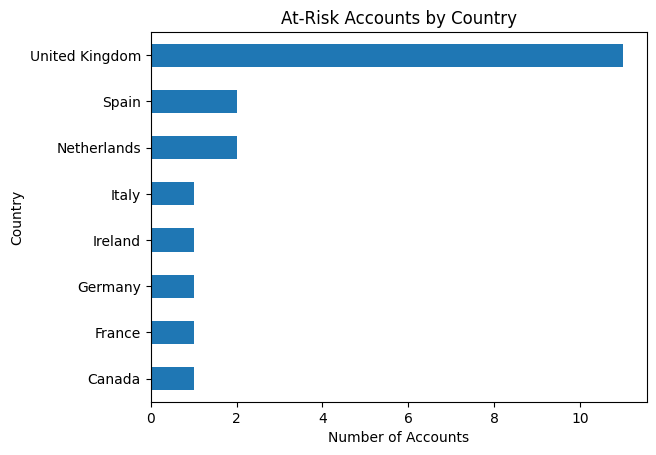

In [161]:
at_risk = result_df[result_df['risk_level'].isin(['Critical', 'High'])]

country_risk = at_risk.groupby('country').size().sort_values()

country_risk.plot(kind='barh')

plt.title("At-Risk Accounts by Country")
plt.xlabel("Number of Accounts")
plt.ylabel("Country")
plt.show()

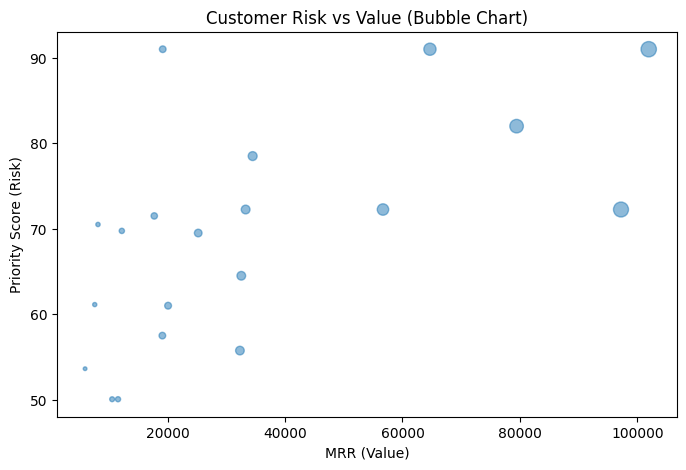

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    result_df['mrr'],
    result_df['priority_score'],
    s=result_df['ANNUAL_CONTRACT_VALUE'] / 10000,  # bubble size
    alpha=0.5
)

plt.title("Customer Risk vs Value (Bubble Chart)")
plt.xlabel("MRR (Value)")
plt.ylabel("Priority Score (Risk)")

plt.show()